# DeepInsightors Team
### SPE DSEATS AFRICA - DATATHON 2025

# A. Data Preparation & Cleaning
**Import Libraries**

In [1]:
# Basic Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
wells_df = pd.read_csv("spe_africa_dseats_datathon_2025_wells_dataset.csv")
reservoir_df = pd.read_csv("reservoir_info.csv")
class_df = pd.read_csv("classification_parameters.csv")

In [3]:
wells_df.head()

,PROD_DATE,WELL_NAME,ON_STREAM_HRS,BOTTOMHOLE_FLOWING_PRESSURE (PSI),DOWNHOLE_TEMPERATURE (deg F),ANNULUS_PRESS (PSI),CHOKE_SIZE (%),WELL_HEAD_PRESSURE (PSI),WELL_HEAD_TEMPERATURE (deg F),CUMULATIVE_OIL_PROD (STB),CUMULATIVE_FORMATION_GAS_PROD (MSCF),CUMULATIVE_TOTAL_GAS_PROD (MSCF),CUMULATIVE_WATER_PROD (BBL)
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [4]:
reservoir_df.head()

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [5]:
class_df.head()

,Reservoir Name,Reservoir Type,Well Type,Production Type,Formation GOR Trend,Watercut Trend,Oil Productivity Index Trend
0,ACHI,Saturated,NF,Steady,aSolGOR,Flat,Flat
1,KEMA,Undersat,GL,Unsteady,bSolGOR,Incr,Incr
2,MAKO,NaN,NaN,NaN,Combo,Decr,Decr
3,DEPU,NaN,NaN,NaN,NaN,Combo,Combo
4,JANI,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
wells_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7955 entries, 0 to 7954
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   PROD_DATE                             7955 non-null   object 
 1   WELL_NAME                             7955 non-null   object 
 2   ON_STREAM_HRS                         7955 non-null   float64
 3   BOTTOMHOLE_FLOWING_PRESSURE (PSI)     7955 non-null   object 
 4   DOWNHOLE_TEMPERATURE (deg F)          7955 non-null   float64
 5   ANNULUS_PRESS (PSI)                   7955 non-null   object 
 6   CHOKE_SIZE (%)                        7955 non-null   float64
 7   WELL_HEAD_PRESSURE (PSI)              7955 non-null   object 
 8   WELL_HEAD_TEMPERATURE (deg F)         7955 non-null   float64
 9   CUMULATIVE_OIL_PROD (STB)             7955 non-null   object 
 10  CUMULATIVE_FORMATION_GAS_PROD (MSCF)  7955 non-null   object 
 11  CUMULATIVE_TOTAL_

In [7]:
wells_df.describe()

,ON_STREAM_HRS,DOWNHOLE_TEMPERATURE (deg F),CHOKE_SIZE (%),WELL_HEAD_TEMPERATURE (deg F)
count,7955.000000,7955.000000,7955.000000,7955.000000
mean,21.623497,168.757429,56.155295,86.836365
std,6.567826,31.917787,34.975408,22.738615
min,0.000000,0.000000,0.000000,0.000000
25%,24.000000,150.228500,28.130855,80.677500
50%,24.000000,158.624000,51.068030,88.364000
75%,24.000000,202.600000,99.800950,96.770500
max,25.000000,212.153000,100.000000,182.157000


## Data Cleaning

**Rename columns for easier handling**

In [8]:
# Rename columns for easier handling
rename_map = {
    "PROD_DATE": "date",
    "WELL_NAME": "well_name",
    "ON_STREAM_HRS": "on_stream_hrs",
    "BOTTOMHOLE_FLOWING_PRESSURE (PSI)": "bhp",
    "DOWNHOLE_TEMPERATURE (deg F)": "downhole_temp",
    "ANNULUS_PRESS (PSI)": "annulus_p",
    "CHOKE_SIZE (%)": "choke_size",
    "WELL_HEAD_PRESSURE (PSI)": "whp",
    "WELL_HEAD_TEMPERATURE (deg F)": "wht",
    "CUMULATIVE_OIL_PROD (STB)": "cum_oil",
    "CUMULATIVE_FORMATION_GAS_PROD (MSCF)": "cum_form_gas",
    "CUMULATIVE_TOTAL_GAS_PROD (MSCF)": "cum_total_gas",
    "CUMULATIVE_WATER_PROD (BBL)": "cum_water"
}
wells_df.rename(columns=rename_map, inplace=True)

In [9]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,15-Feb-14,Well_#1,0.0,"4,050",189.866,0,1.17951,482.46,50.864,0,0,0,0
1,16-Feb-14,Well_#1,0.0,"3,961",189.945,0,2.99440,328.601,47.668,0,0,0,0
2,17-Feb-14,Well_#1,0.0,"3,961",190.004,0,1.90349,387.218,48.962,0,0,0,0
3,18-Feb-14,Well_#1,0.0,"3,964",190.020,0,0.00000,308.98,46.636,0,0,0,0
4,19-Feb-14,Well_#1,0.0,"3,965",190.107,0,30.20760,196.057,47.297,0,0,0,0


In [10]:
# Clean numeric fields (remove commas, convert to float)
for col in ["bhp","annulus_p","whp","cum_oil","cum_form_gas","cum_total_gas","cum_water"]:
    wells_df[col] = wells_df[col].astype(str).str.replace(",", "").astype(float)

In [11]:
# Convert date
wells_df["date"] = pd.to_datetime(wells_df["date"], format="%d-%b-%y", errors="coerce")

In [12]:
# Clean well names
wells_df["well_name"] = wells_df["well_name"].str.replace("Well_#", "").astype(int)

In [13]:
wells_df.head()

,date,well_name,on_stream_hrs,bhp,downhole_temp,annulus_p,choke_size,whp,wht,cum_oil,cum_form_gas,cum_total_gas,cum_water
0,2014-02-15,1,0.0,4050.0,189.866,0.0,1.17951,482.460,50.864,0.0,0.0,0.0,0.0
1,2014-02-16,1,0.0,3961.0,189.945,0.0,2.99440,328.601,47.668,0.0,0.0,0.0,0.0
2,2014-02-17,1,0.0,3961.0,190.004,0.0,1.90349,387.218,48.962,0.0,0.0,0.0,0.0
3,2014-02-18,1,0.0,3964.0,190.020,0.0,0.00000,308.980,46.636,0.0,0.0,0.0,0.0
4,2014-02-19,1,0.0,3965.0,190.107,0.0,30.20760,196.057,47.297,0.0,0.0,0.0,0.0


**Check for Missing Values**

In [14]:
wells_df.isnull().sum()

date             0
well_name        0
on_stream_hrs    0
bhp              0
downhole_temp    0
annulus_p        0
choke_size       0
whp              0
wht              0
cum_oil          0
cum_form_gas     0
cum_total_gas    0
cum_water        0
dtype: int64

**Check for Duplicates**

In [15]:
wells_df.duplicated().sum()

0

# B. Empirical Analysis (Feature Engineering Calculations)

### Daily production

In [16]:
# Daily production
wells_df["oil_day"] = wells_df.groupby("well_name")["cum_oil"].diff()
wells_df["gas_day"] = wells_df.groupby("well_name")["cum_total_gas"].diff()
wells_df["water_day"] = wells_df.groupby("well_name")["cum_water"].diff()

Daily production columns added:


,date,well_name,oil_day,gas_day,water_day
0,2014-02-15,1,NaN,NaN,NaN
1,2014-02-16,1,0.0,0.0,0.0
2,2014-02-17,1,0.0,0.0,0.0
3,2014-02-18,1,0.0,0.0,0.0
4,2014-02-19,1,0.0,0.0,0.0
5,2014-02-20,1,0.0,0.0,0.0
6,2014-02-21,1,0.0,0.0,0.0
7,2014-02-22,1,0.0,0.0,0.0
8,2014-02-23,1,0.0,0.0,0.0
9,2014-02-24,1,0.0,0.0,0.0


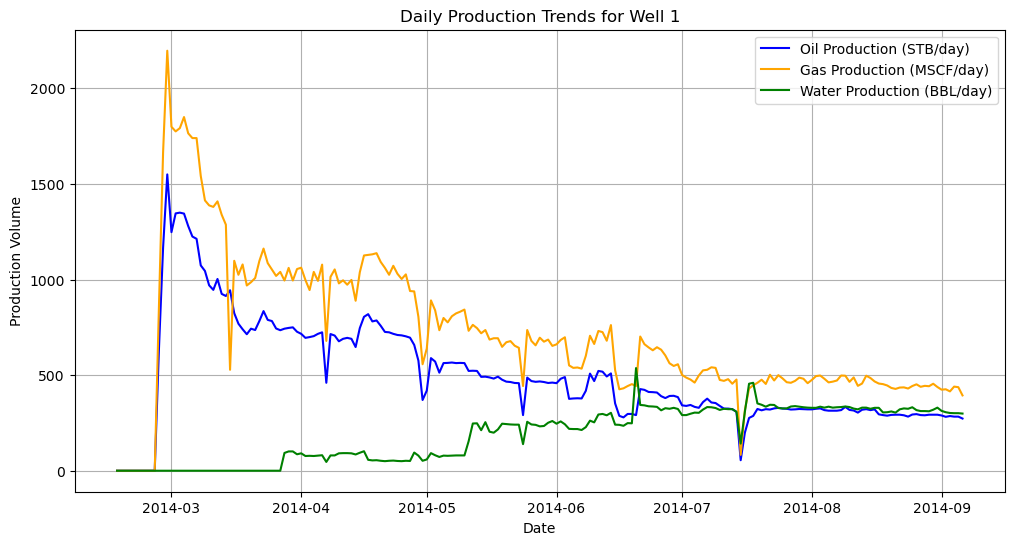

In [17]:
# Display first few rows to check calculations
print("Daily production columns added:")
display(wells_df[["date","well_name","oil_day","gas_day","water_day"]].head(20))

# Quick visualization for one well
subset = wells_df[wells_df["well_name"]==1].sort_values("date")
plt.figure(figsize=(12,6))
plt.plot(subset["date"], subset["oil_day"], label="Oil Production (STB/day)", color="blue")
plt.plot(subset["date"], subset["gas_day"], label="Gas Production (MSCF/day)", color="orange")
plt.plot(subset["date"], subset["water_day"], label="Water Production (BBL/day)", color="green")
plt.title("Daily Production Trends for Well 1")
plt.xlabel("Date")
plt.ylabel("Production Volume")
plt.legend()
plt.grid(True)
plt.show()


# 1. Reservoir Identification
**Fix Reservoir Data Types**

In [18]:
reservoir_df.head()

,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,"3,500","3,300","2,700",800,1.20
1,KEMA,"4,200","4,000","3,900",600,1.45
2,MAKO,"3,500","3,500","3,000",500,1.15
3,DEPU,"2,800","2,800","2,400","1,200",1.37
4,JANI,"4,500","4,300","4,200","1,000",1.30


In [19]:
# Convert reservoir numeric columns to float
for col in ["Initial Reservoir Pressure (PSI)",
            "Bubble Point Pressure (PSI)",
            "Current Average Reservoir Pressure (PSI)",
            "Solution Gas-Oil-Ratio (SCF/BBL)"]:
    reservoir_df[col] = reservoir_df[col].astype(str).str.replace(",", "").astype(float)

# Check types
print(reservoir_df.dtypes)
display(reservoir_df)

Reservoir Name                               object
Initial Reservoir Pressure (PSI)            float64
Bubble Point Pressure (PSI)                 float64
Current Average Reservoir Pressure (PSI)    float64
Solution Gas-Oil-Ratio (SCF/BBL)            float64
Formation Volume Factor (RB/STB)            float64
dtype: object


,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Current Average Reservoir Pressure (PSI),Solution Gas-Oil-Ratio (SCF/BBL),Formation Volume Factor (RB/STB)
0,ACHI,3500.0,3300.0,2700.0,800.0,1.20
1,KEMA,4200.0,4000.0,3900.0,600.0,1.45
2,MAKO,3500.0,3500.0,3000.0,500.0,1.15
3,DEPU,2800.0,2800.0,2400.0,1200.0,1.37
4,JANI,4500.0,4300.0,4200.0,1000.0,1.30


**Reservoir Identification Function code**

In [20]:
# Reservoir Identification
def assign_reservoir(max_bhp, reservoir_df, tolerance=200):
    for _, row in reservoir_df.iterrows():
        diff = row["Initial Reservoir Pressure (PSI)"] - max_bhp
        if 0 <= diff <= tolerance:
            return row["Reservoir Name"]
    return None

**Apply Reservoir Identification function code**

In [21]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp":"max_bhp"}, inplace=True)

# Assign reservoir for each well
max_bhp_df["Reservoir"] = max_bhp_df["max_bhp"].apply(lambda x: assign_reservoir(x, reservoir_df))

# Display first 20 wells with reservoir assignment
print("Reservoir assignment based on max bottomhole pressure:")
display(max_bhp_df.head(20))

Reservoir assignment based on max bottomhole pressure:


,well_name,max_bhp,Reservoir
0,1,4096.0,KEMA
1,2,3735.0,None
2,3,2985.0,None
3,4,2340.0,None
4,5,2933.0,None
5,6,3797.0,None
6,7,3821.0,None
7,8,2681.0,DEPU
8,9,2333.0,None
9,10,4051.0,KEMA


**Visualize Reservoir Assignment**

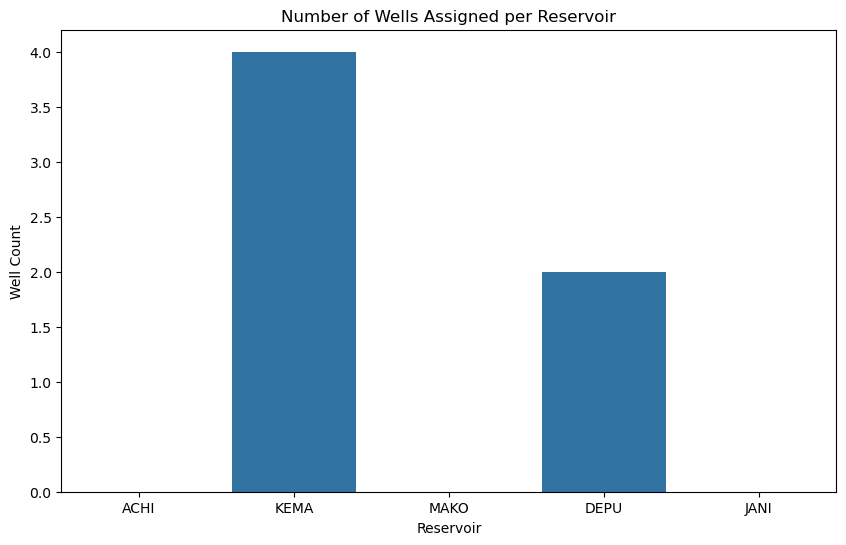

In [22]:
# Bar plot of wells assigned to reservoirs
plt.figure(figsize=(10,6))
sns.countplot(x="Reservoir", data=max_bhp_df, order=reservoir_df["Reservoir Name"])
plt.title("Number of Wells Assigned per Reservoir")
plt.xlabel("Reservoir")
plt.ylabel("Well Count")
plt.show()

# Observation
The issue is that the strict ≤200 psi cutoff only matches a few wells which are (KEMA and DEPU). Instead, we’ll assign each well to the closest reservoir pressure (Initial or Current Average), which guarantees every well is classified.

**Reservoir Identification (Closest Reservoir)**

In [23]:
def assign_reservoir_closest(max_bhp, reservoir_df, use_current=True):
    """
    Assign reservoir based on closest pressure match.
    If use_current=True, compare against current average reservoir pressure.
    Otherwise, use initial reservoir pressure.
    """
    if use_current:
        diffs = reservoir_df["Current Average Reservoir Pressure (PSI)"] - max_bhp
    else:
        diffs = reservoir_df["Initial Reservoir Pressure (PSI)"] - max_bhp
    
    # Only consider positive differences (reservoir pressure >= BHP)
    diffs = diffs[diffs >= 0]
    if len(diffs) == 0:
        return "Unassigned"
    
    closest_idx = diffs.idxmin()
    return reservoir_df.loc[closest_idx, "Reservoir Name"]

**Apply Reservoir Identification**

In [24]:
# Calculate max bottomhole pressure per well
max_bhp_df = wells_df.groupby("well_name")["bhp"].max().reset_index()
max_bhp_df.rename(columns={"bhp":"max_bhp"}, inplace=True)

# Assign reservoir using closest match
max_bhp_df["Reservoir"] = max_bhp_df["max_bhp"].apply(lambda x: assign_reservoir_closest(x, reservoir_df, use_current=True))

# Display first 20 wells with reservoir assignment
print("Reservoir assignment based on closest pressure match:")
display(max_bhp_df.head(20))

Reservoir assignment based on closest pressure match:


,well_name,max_bhp,Reservoir
0,1,4096.0,JANI
1,2,3735.0,KEMA
2,3,2985.0,MAKO
3,4,2340.0,DEPU
4,5,2933.0,MAKO
5,6,3797.0,KEMA
6,7,3821.0,KEMA
7,8,2681.0,ACHI
8,9,2333.0,DEPU
9,10,4051.0,JANI


**Visualize Reservoir Assignment**

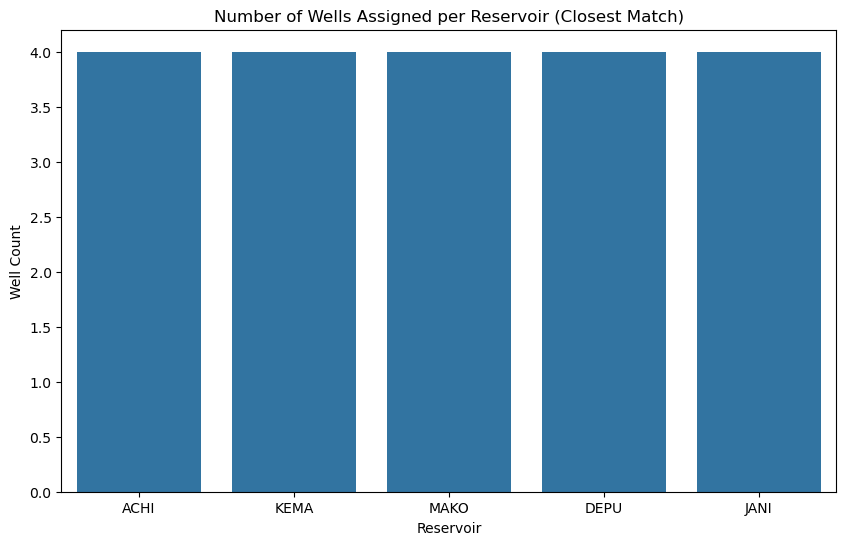

In [25]:
# Bar plot of wells assigned to reservoirs
plt.figure(figsize=(10,6))
sns.countplot(x="Reservoir", data=max_bhp_df, order=reservoir_df["Reservoir Name"])
plt.title("Number of Wells Assigned per Reservoir (Closest Match)")
plt.xlabel("Reservoir")
plt.ylabel("Well Count");

### Summary
* Instead of requiring a strict ≤200 psi difference, we now assign each well to the closest reservoir pressure.
* This ensures all wells are classified into one of the five reservoirs.

## 2. Reservoir Type Classification
**Define Reservoir Type Function**

In [26]:
# Reservoir Type classification
def check_saturation(res_row):
    """
    Reservoir is Saturated if Initial Pressure <= Bubble Point Pressure,
    otherwise Undersaturated.
    """
    return "Saturated" if res_row["Initial Reservoir Pressure (PSI)"] <= res_row["Bubble Point Pressure (PSI)"] else "Undersat"

**Apply Reservoir Type to All Reservoirs**

In [27]:
# Apply saturation check to each reservoir row
reservoir_df["Reservoir Type"] = reservoir_df.apply(check_saturation, axis=1)

# Display results
print("Reservoir Type Classification:")
display(reservoir_df[["Reservoir Name","Initial Reservoir Pressure (PSI)","Bubble Point Pressure (PSI)","Reservoir Type"]])

Reservoir Type Classification:


,Reservoir Name,Initial Reservoir Pressure (PSI),Bubble Point Pressure (PSI),Reservoir Type
0,ACHI,3500.0,3300.0,Undersat
1,KEMA,4200.0,4000.0,Undersat
2,MAKO,3500.0,3500.0,Saturated
3,DEPU,2800.0,2800.0,Saturated
4,JANI,4500.0,4300.0,Undersat


**Visualize Reservoir Types**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18672\759706547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Reservoir Type", data=reservoir_df, palette="Set2")


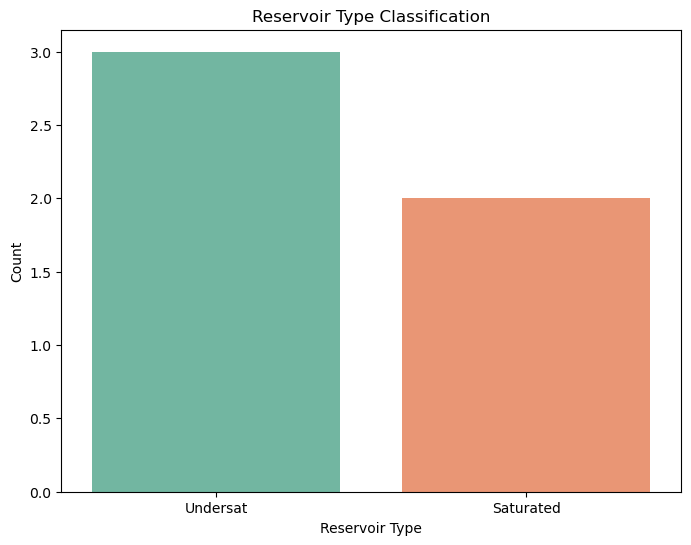

In [28]:
# Bar chart of reservoir types
plt.figure(figsize=(8,6))
sns.countplot(x="Reservoir Type", data=reservoir_df, palette="Set2")
plt.title("Reservoir Type Classification")
plt.xlabel("Reservoir Type")
plt.ylabel("Count");

### Summary
* Function defined for reservoir type classification.
* Table output showing each reservoir’s initial pressure, bubble point, and type (Saturated/Undersat).

## 3. Flow Mechanism Classification
**Define Flow Mechanism Function**

In [29]:
# Flow Mechanism classification
def classify_well_type(subset):
    """
    Classify wells based on annulus pressure.
    GL = Gas Lift (if annulus pressure > 0)
    NF = Naturally Flowing (if annulus pressure = 0)
    """
    return "GL" if subset["annulus_p"].mean() > 0 else "NF"

**Apply Flow Mechanism to All Wells**

In [30]:
# Apply classification for each well
flow_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"]==well]
    flow_results.append({
        "well_name": well,
        "Flow Mechanism": classify_well_type(subset)
    })

flow_df = pd.DataFrame(flow_results)

# Display results
print("Flow Mechanism Classification for Wells:")
display(flow_df.head(20))

Flow Mechanism Classification for Wells:


,well_name,Flow Mechanism
0,1,GL
1,2,NF
2,3,GL
3,4,GL
4,5,GL
5,6,GL
6,7,GL
7,8,GL
8,9,GL
9,10,GL


**Visualize Flow Mechanism Distribution**

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18672\3544818338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Flow Mechanism", data=flow_df, palette="Set2")


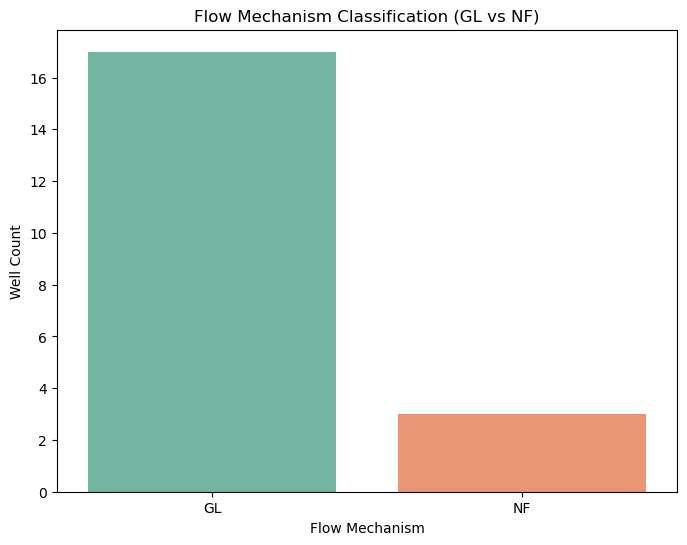

In [31]:
# Bar chart of flow mechanism types
plt.figure(figsize=(8,6))
sns.countplot(x="Flow Mechanism", data=flow_df, palette="Set2")
plt.title("Flow Mechanism Classification (GL vs NF)")
plt.xlabel("Flow Mechanism")
plt.ylabel("Well Count");

### Summary
* Function defined for flow mechanism classification.
* Table output showing each well and whether it is Gas Lift (GL) or Naturally Flowing (NF).

# C. Well Performance Analysis

## 1. Production Stability Function

In [32]:
# Production Stability Analysis

steady_unsteady_status = {}

# Get all wells
all_wells = wells_df['well_name'].unique()

for w_ in all_wells:
    wl = wells_df[wells_df['well_name'] == w_].copy()

    # Sort by date
    wl.sort_values('date', ascending=True, inplace=True)

    # Calculate rate drop percentage based on daily oil production
    wl['rate_drop'] = ((wl['oil_day'].shift(1) - wl['oil_day']) / (wl['oil_day'].shift(1) + 0.000001)) * 100

    # Get min and max dates
    min_date, max_date = wl.date.min(), wl.date.max()

    curr_date = min_date
    while curr_date < max_date:
        next_date = curr_date + pd.DateOffset(months=6)
        wl_window = wl[(wl['date'] > curr_date) & (wl['date'] <= next_date)]

        # Calculate time span in months
        date_diff = (wl_window['date'].max() - wl_window['date'].min()).days / 30

        # Maximum drop in this window
        max_drop = wl_window['rate_drop'].max()

        # Classification rule
        if max_drop > 50 and date_diff >= 3 and date_diff <= 6.1:
            print(f"Well {w_}: {max_drop:.2f}% drop → Unsteady")
            steady_unsteady_status[w_] = 'Unsteady'
            break
        else:
            print(f"Well {w_}: {date_diff:.1f} months, {max_drop:.2f}% drop → Steady")
            steady_unsteady_status[w_] = 'Steady'
            break

        curr_date += pd.DateOffset(months=6)

# Convert results to DataFrame for easy viewing
stability_df = pd.DataFrame(list(steady_unsteady_status.items()), columns=['well_name','Stability'])

Well 1: 82.14% drop → Unsteady
Well 2: 100.00% drop → Unsteady
Well 3: 100.00% drop → Unsteady
Well 4: 70.83% drop → Unsteady
Well 5: 100.00% drop → Unsteady
Well 6: 100.00% drop → Unsteady
Well 7: 77.45% drop → Unsteady
Well 8: 100.00% drop → Unsteady
Well 9: 87.72% drop → Unsteady
Well 10: 100.00% drop → Unsteady
Well 11: 100.00% drop → Unsteady
Well 12: 100.00% drop → Unsteady
Well 13: 100.00% drop → Unsteady
Well 14: 6.1 months, 37.18% drop → Steady
Well 15: 100.00% drop → Unsteady
Well 16: 6.1 months, 49.05% drop → Steady
Well 17: 87.71% drop → Unsteady
Well 18: 100.00% drop → Unsteady
Well 19: 6.1 months, 25.41% drop → Steady
Well 20: 100.00% drop → Unsteady


### Summary
* Function defined for production stability classification.
* Table output showing each well as Steady or Unsteady.

## 2. Gas–Oil Ratio (GOR) Trend classification
* GOR = Cumulative Gas Produced / Cumulative Oil Produced
* aSolGOR: If GOR increases consistently over time
* bSolGOR: If GOR decreases consistently
* Combo: If GOR fluctuates, or combination the two

$$
GOR = \frac{\text{Gas Production (MSCF)}}{\text{Oil Production (STB)}}
$$

In [33]:
# Calculate daily production rates
wells_df["oil_day"] = wells_df.groupby("well_name")["cum_oil"].diff()
wells_df["gas_day"] = wells_df.groupby("well_name")["cum_total_gas"].diff()
wells_df["water_day"] = wells_df.groupby("well_name")["cum_water"].diff()

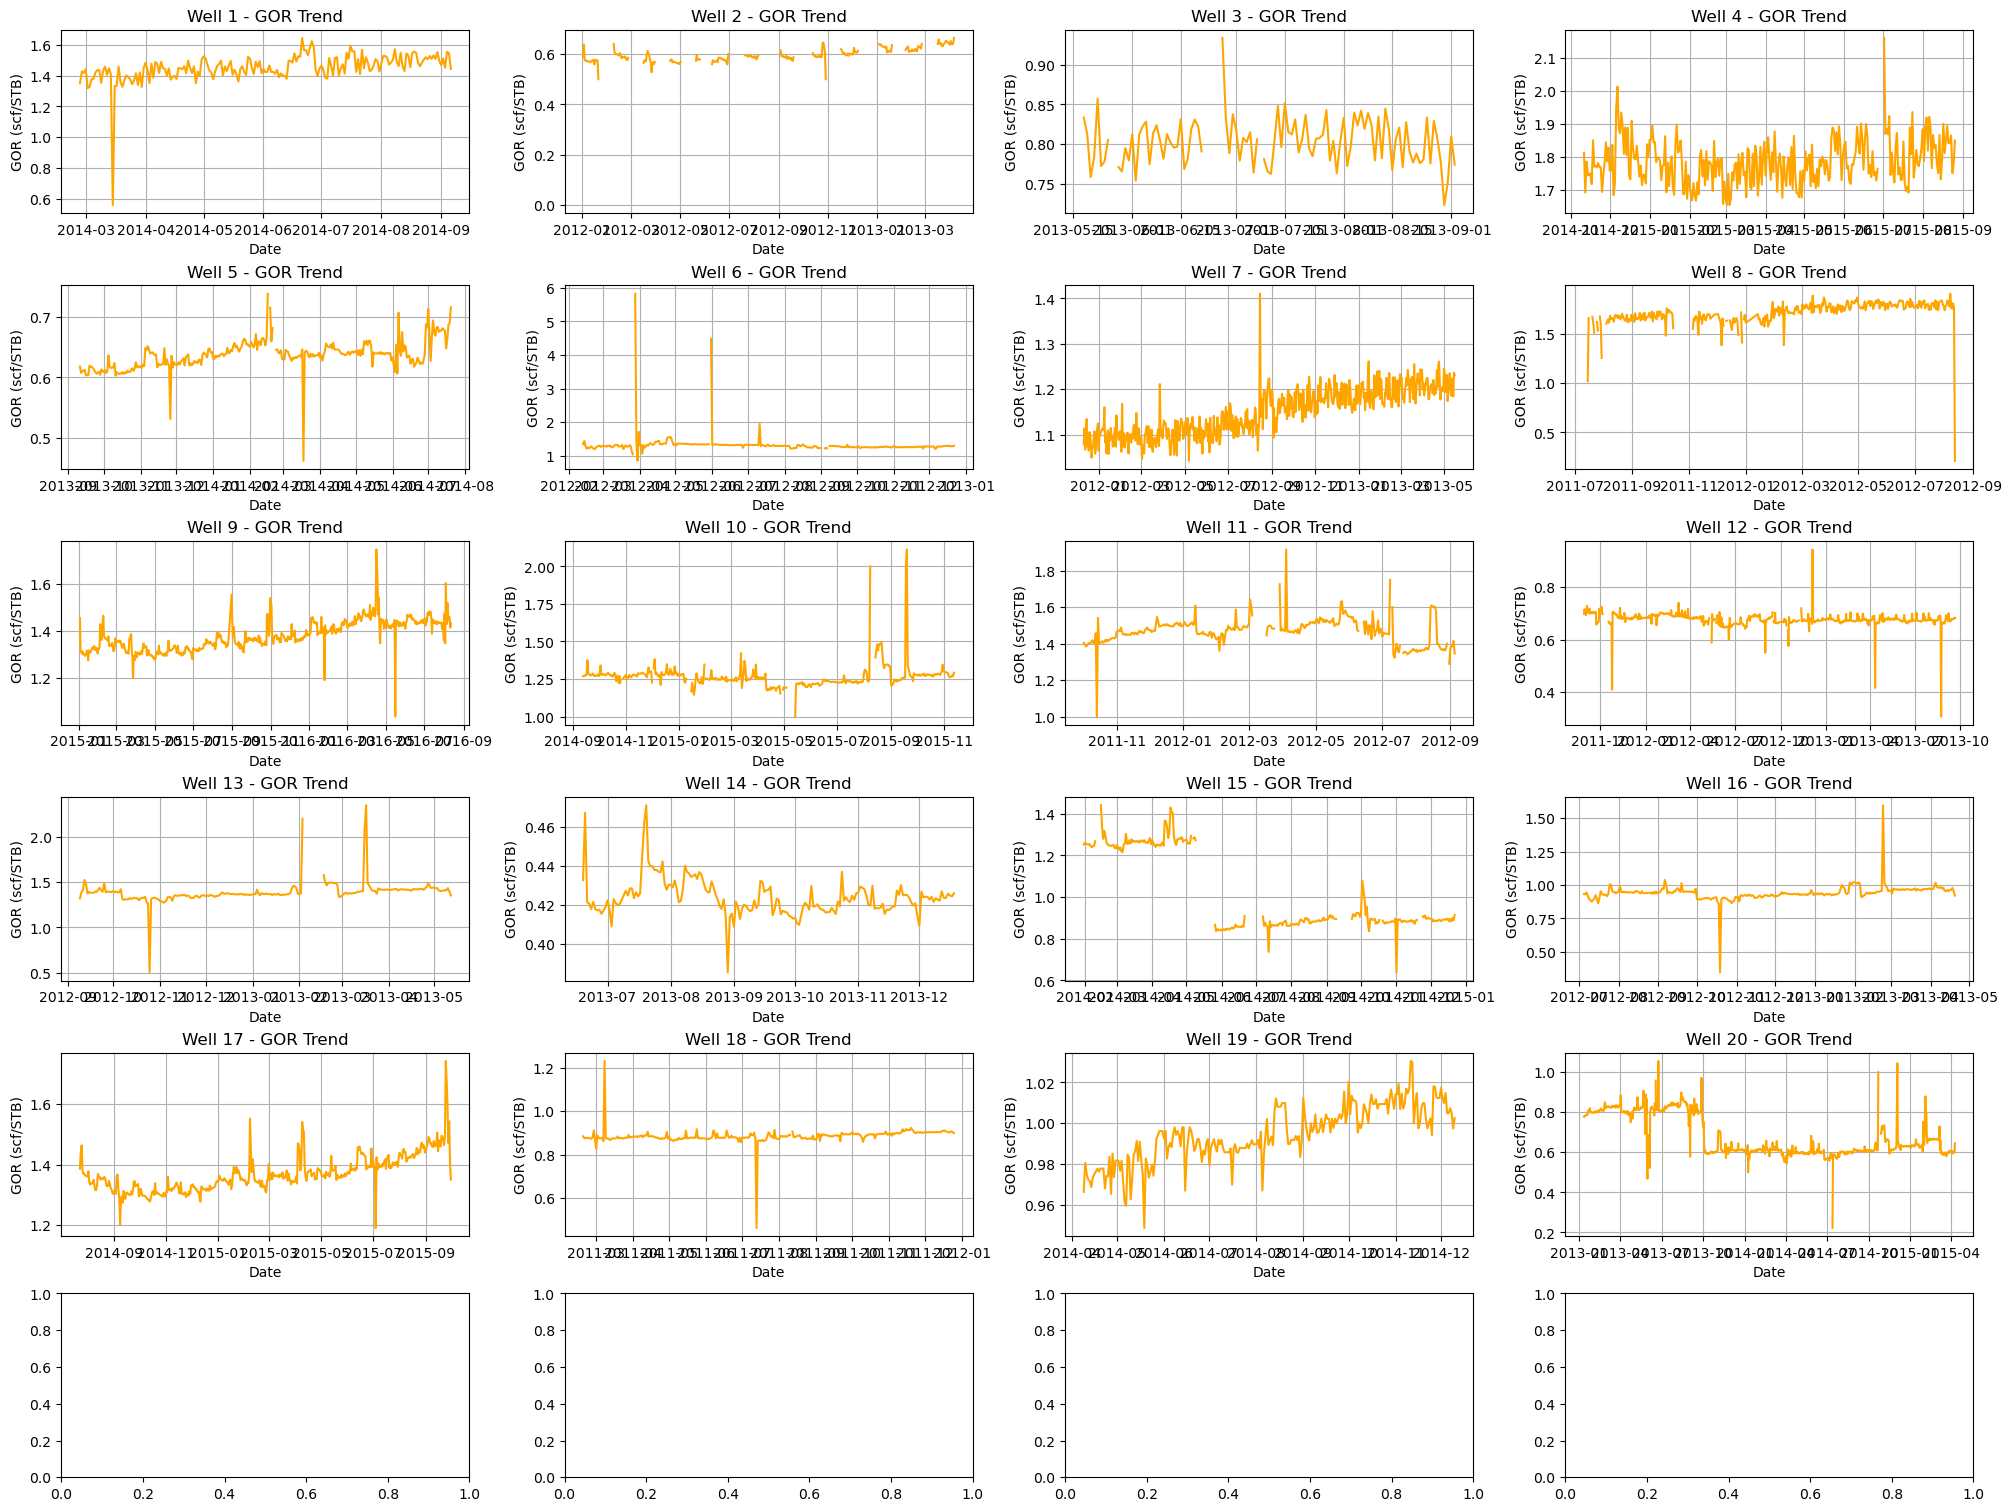

In [34]:
# Gas-Oil Ratio calculation
wells_df["gor"] = wells_df["gas_day"] / wells_df["oil_day"].replace(0, np.nan)

# Plot GOR trends per well
def plot_gor(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4+1, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["gor"], color="orange")
        axes[i].set_title(f"Well {well} - GOR Trend")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("GOR (scf/STB)")
        axes[i].grid()
    plt.show()

plot_gor(wells_df)

## 3. Watercut Trend
* Flat: watercut remains steady
* Incr: watercut increases over time
* Decr: watercut decreases over time
* Combo: inconsistent or mixed trend

$$
\text{Watercut} = \frac{\text{Water Production}}{\text{Oil Production} + \text{Water Production}}
$$

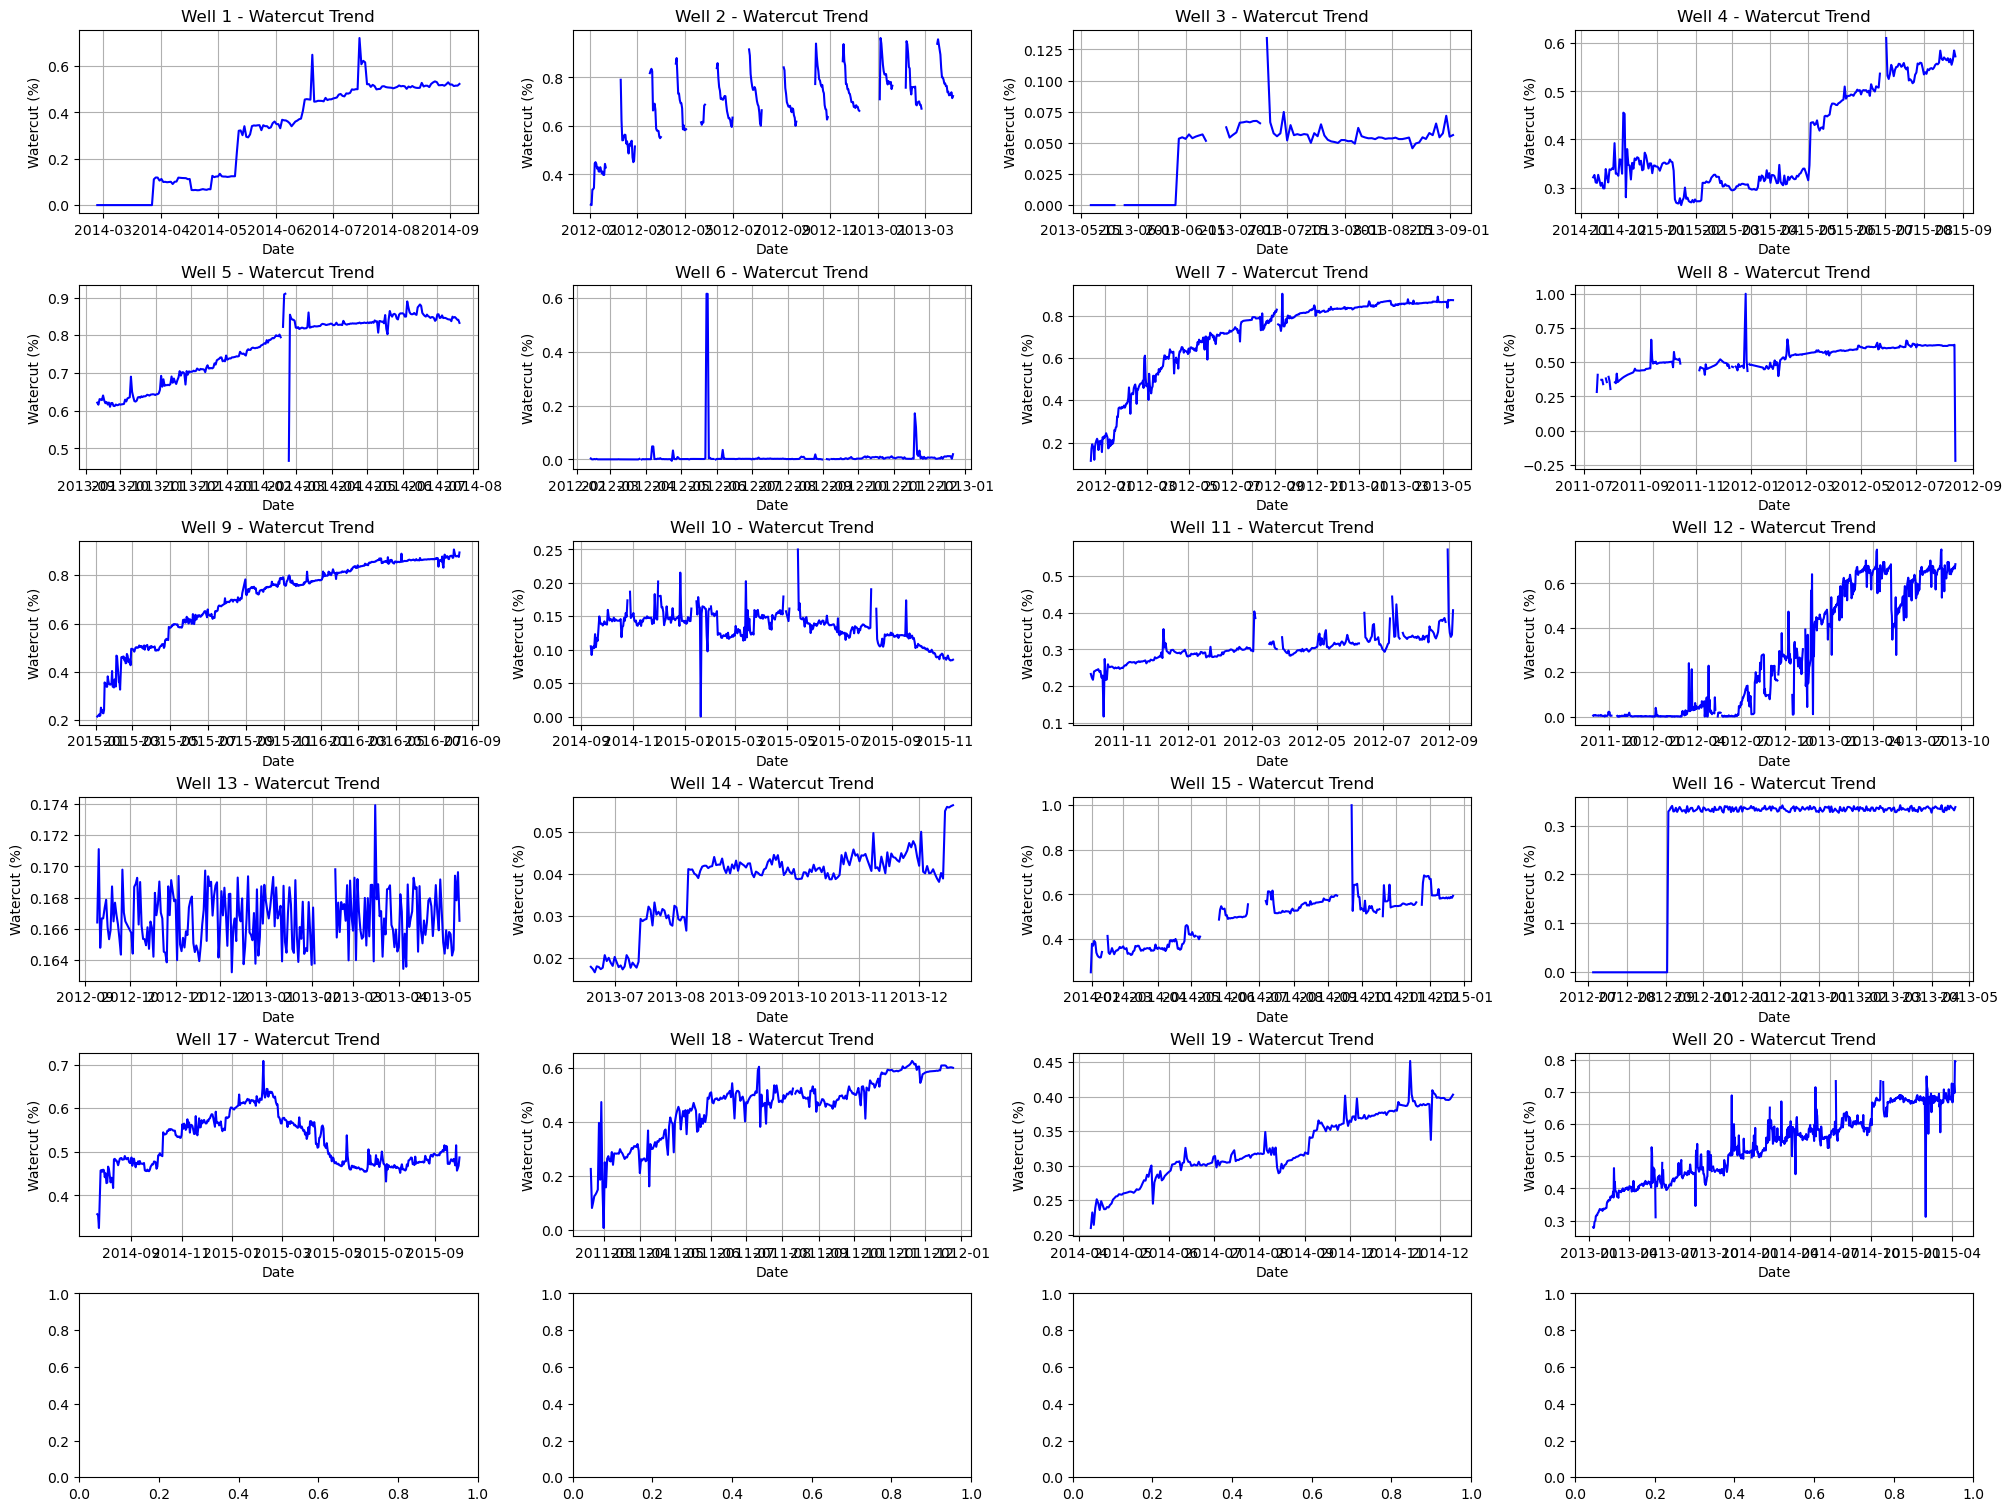

In [35]:
# Watercut calculation
wells_df["watercut"] = wells_df["water_day"] / (wells_df["oil_day"] + wells_df["water_day"]).replace(0, np.nan)

# Plot Watercut trends per well
def plot_watercut(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4+1, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["watercut"], color="blue")
        axes[i].set_title(f"Well {well} - Watercut Trend")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("Watercut (%)")
        axes[i].grid()
    plt.show()

plot_watercut(wells_df)

## 4 Productivity Index Trend
* Flat – no significant change in PI
* Incr – PI increasing over time
* Decr – PI decreasing over time
* Combo – inconsistent or mixed PI behavior

$$
PI = \frac{\text{Oil Production (STB/day)}}{\text{Reservoir Pressure} - \text{Bottomhole Pressure}}
$$

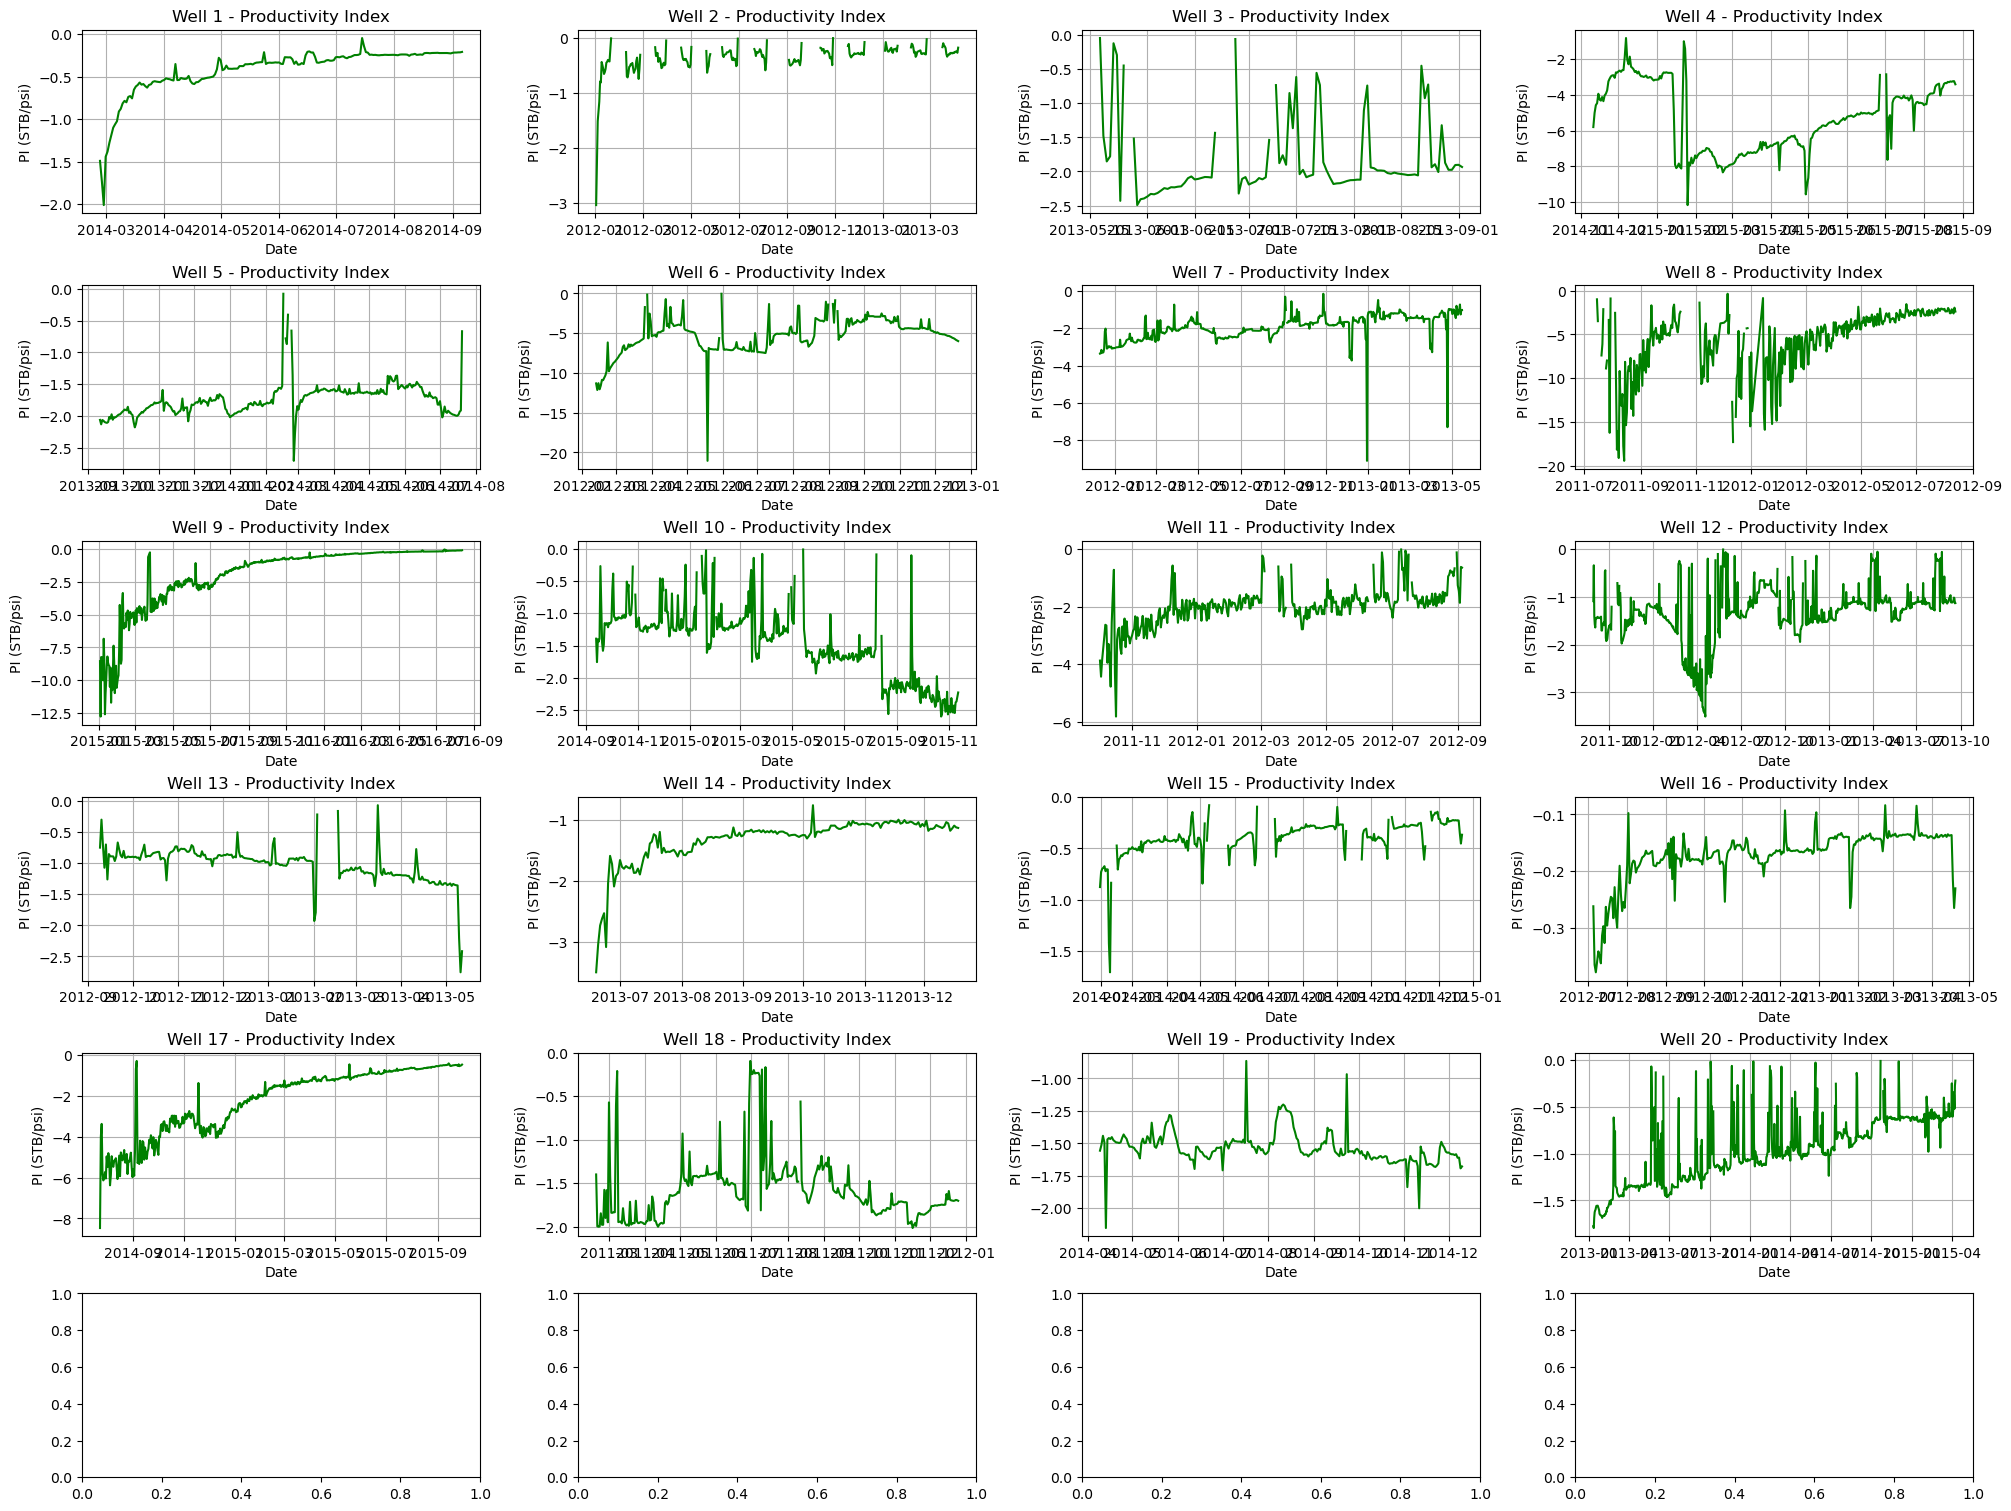

In [36]:
# Create reservoir mapping
res_map = dict(zip(max_bhp_df["well_name"], max_bhp_df["Reservoir"]))
avg_pressures = dict(zip(reservoir_df["Reservoir Name"], reservoir_df["Current Average Reservoir Pressure (PSI)"]))

wells_df["pi"] = wells_df.apply(
    lambda row: row["oil_day"] / (row["bhp"] - avg_pressures.get(res_map.get(row["well_name"], ""), np.nan))
    if row["oil_day"] > 0 else np.nan, axis=1
)

# Plot PI trends per well
def plot_pi(df):
    wells = df["well_name"].unique()
    fig, axes = plt.subplots(len(wells)//4+1, 4, figsize=(20, 15), constrained_layout=True)
    axes = axes.flatten()
    for i, well in enumerate(wells):
        subset = df[df["well_name"] == well].sort_values("date")
        axes[i].plot(subset["date"], subset["pi"], color="green")
        axes[i].set_title(f"Well {well} - Productivity Index")
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("PI (STB/psi)")
        axes[i].grid()
    plt.show()

plot_pi(wells_df)

## Trend Classification (based on β slope) for GOR, Watercut and PI
*  If β ≤ 0.0005 → Flat
*  If β > 0.0005 → Increasing
*  If β < -0.0005 → Decreasing
*  Otherwise → Combo

In [37]:
from sklearn.linear_model import LinearRegression

def classify_trend(series):
    series = series.dropna()
    if len(series) < 2:
        return "Insufficient Data"
    X = np.arange(len(series)).reshape(-1,1)
    y = series.values
    model = LinearRegression().fit(X, y)
    beta = model.coef_[0]
    if abs(beta) <= 0.0005:
        return "Flat"
    elif beta > 0.0005:
        return "Increasing"
    elif beta < -0.0005:
        return "Decreasing"
    else:
        return "Combo"

# Apply classification for each well
trend_results = []
for well in wells_df["well_name"].unique():
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    trend_results.append({
        "well_name": well,
        "GOR Trend": classify_trend(subset["gor"]),
        "Watercut Trend": classify_trend(subset["watercut"]),
        "PI Trend": classify_trend(subset["pi"])
    })

trend_df = pd.DataFrame(trend_results)
print(trend_df.head(20))

    well_name   GOR Trend Watercut Trend    PI Trend
0           1  Increasing     Increasing  Increasing
1           2        Flat     Increasing  Increasing
2           3        Flat     Increasing        Flat
3           4        Flat     Increasing  Decreasing
4           5        Flat     Increasing  Increasing
5           6        Flat           Flat  Increasing
6           7        Flat     Increasing  Increasing
7           8  Increasing     Increasing  Increasing
8           9        Flat     Increasing  Increasing
9          10        Flat           Flat  Decreasing
10         11        Flat           Flat  Increasing
11         12        Flat     Increasing  Increasing
12         13  Increasing           Flat  Decreasing
13         14        Flat           Flat  Increasing
14         15  Decreasing     Increasing  Increasing
15         16        Flat     Increasing        Flat
16         17        Flat           Flat  Increasing
17         18        Flat     Increasing      

# 3. Exploratory Data Analysis (EDA)
### Reservoir pressure trends

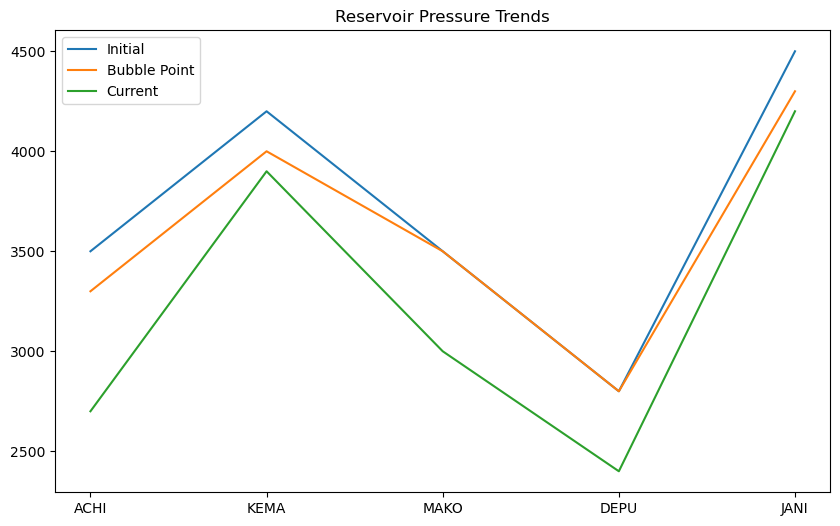

In [38]:
# Reservoir pressure trends
plt.figure(figsize=(10,6))
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Initial Reservoir Pressure (PSI)"], label="Initial")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Bubble Point Pressure (PSI)"], label="Bubble Point")
plt.plot(reservoir_df["Reservoir Name"], reservoir_df["Current Average Reservoir Pressure (PSI)"], label="Current")
plt.title("Reservoir Pressure Trends")
plt.legend()
plt.show()

### Plot Solution Gas-Oil Ratio

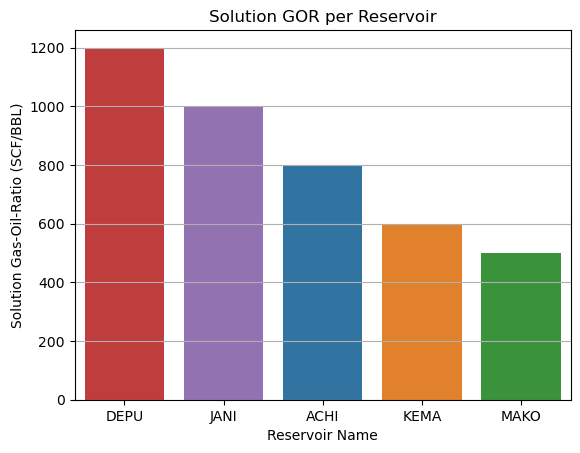

In [39]:
# Plot Solution Gas-Oil Ratio
order = ['DEPU', 'JANI', 'ACHI', 'KEMA', 'MAKO']
sns.barplot(x='Reservoir Name', y='Solution Gas-Oil-Ratio (SCF/BBL)', data=reservoir_df, hue='Reservoir Name', order=order)
plt.title('Solution GOR per Reservoir')
plt.grid(axis='y');

### Oil & Gas rolling trends for four example wells

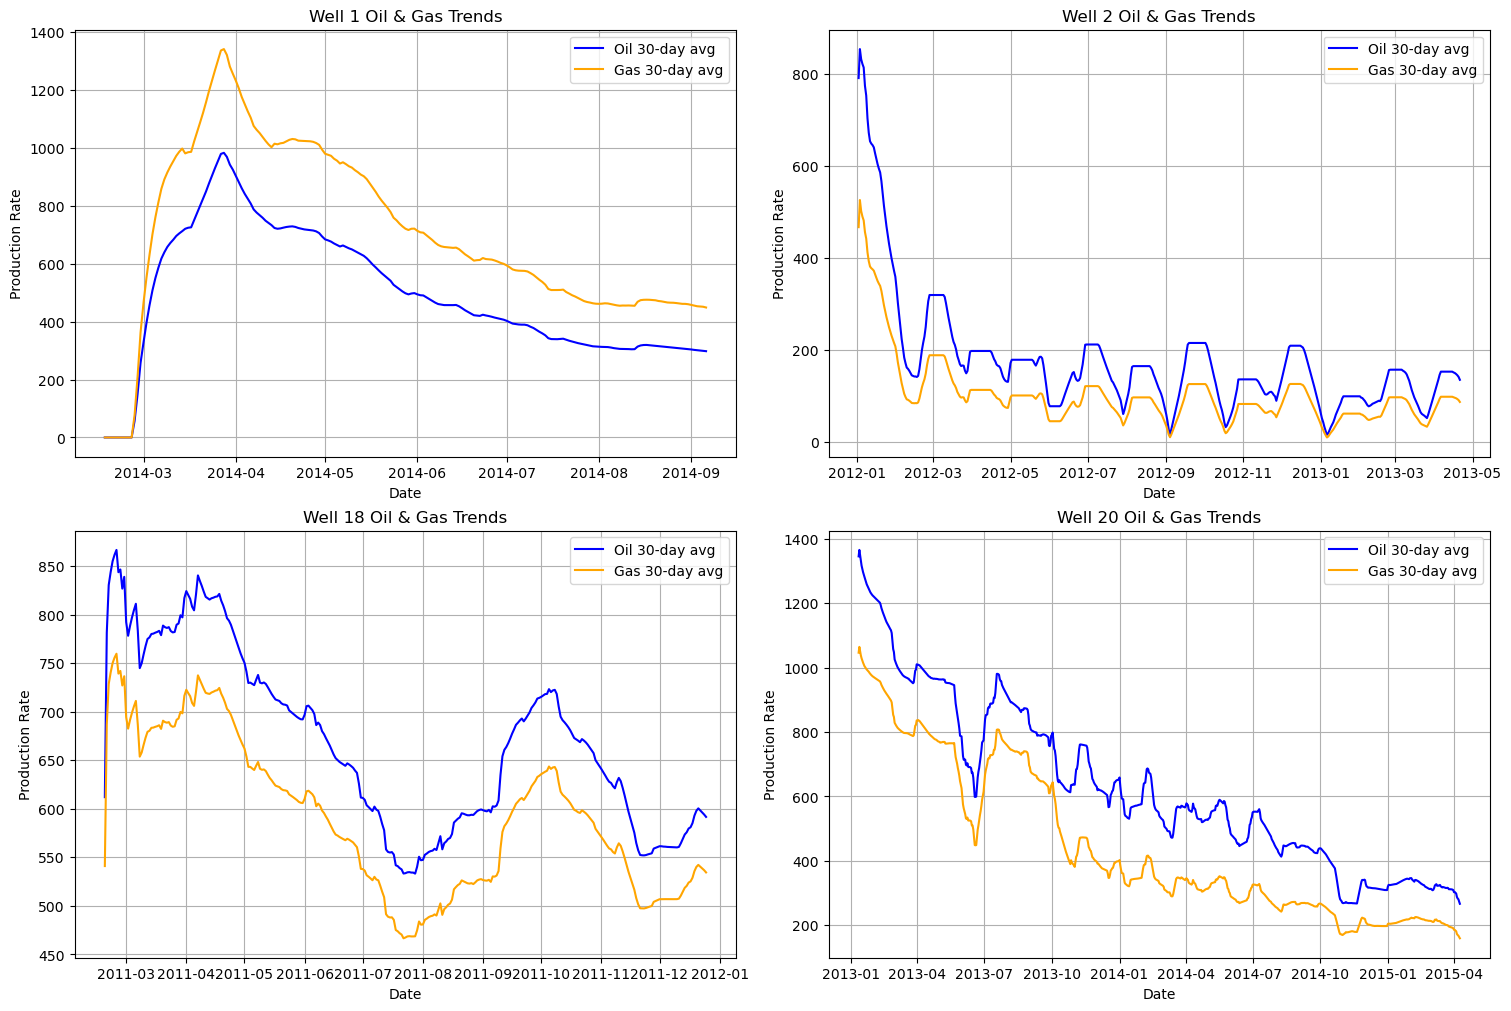

In [40]:
# Oil & Gas rolling trends for four wells
wells_to_plot = [1, 2, 18, 20]   # choose any four well numbers
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

for i, well in enumerate(wells_to_plot):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    subset["oil_roll"] = subset["oil_day"].rolling(30, min_periods=1).mean()
    subset["gas_roll"] = subset["gas_day"].rolling(30, min_periods=1).mean()
    
    axes[i].plot(subset["date"], subset["oil_roll"], label="Oil 30-day avg", color="blue")
    axes[i].plot(subset["date"], subset["gas_roll"], label="Gas 30-day avg", color="orange")
    axes[i].set_title(f"Well {well} Oil & Gas Trends")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Production Rate")
    axes[i].legend()
    axes[i].grid(True)

plt.show()

### Time-Series Visualization Across Wells

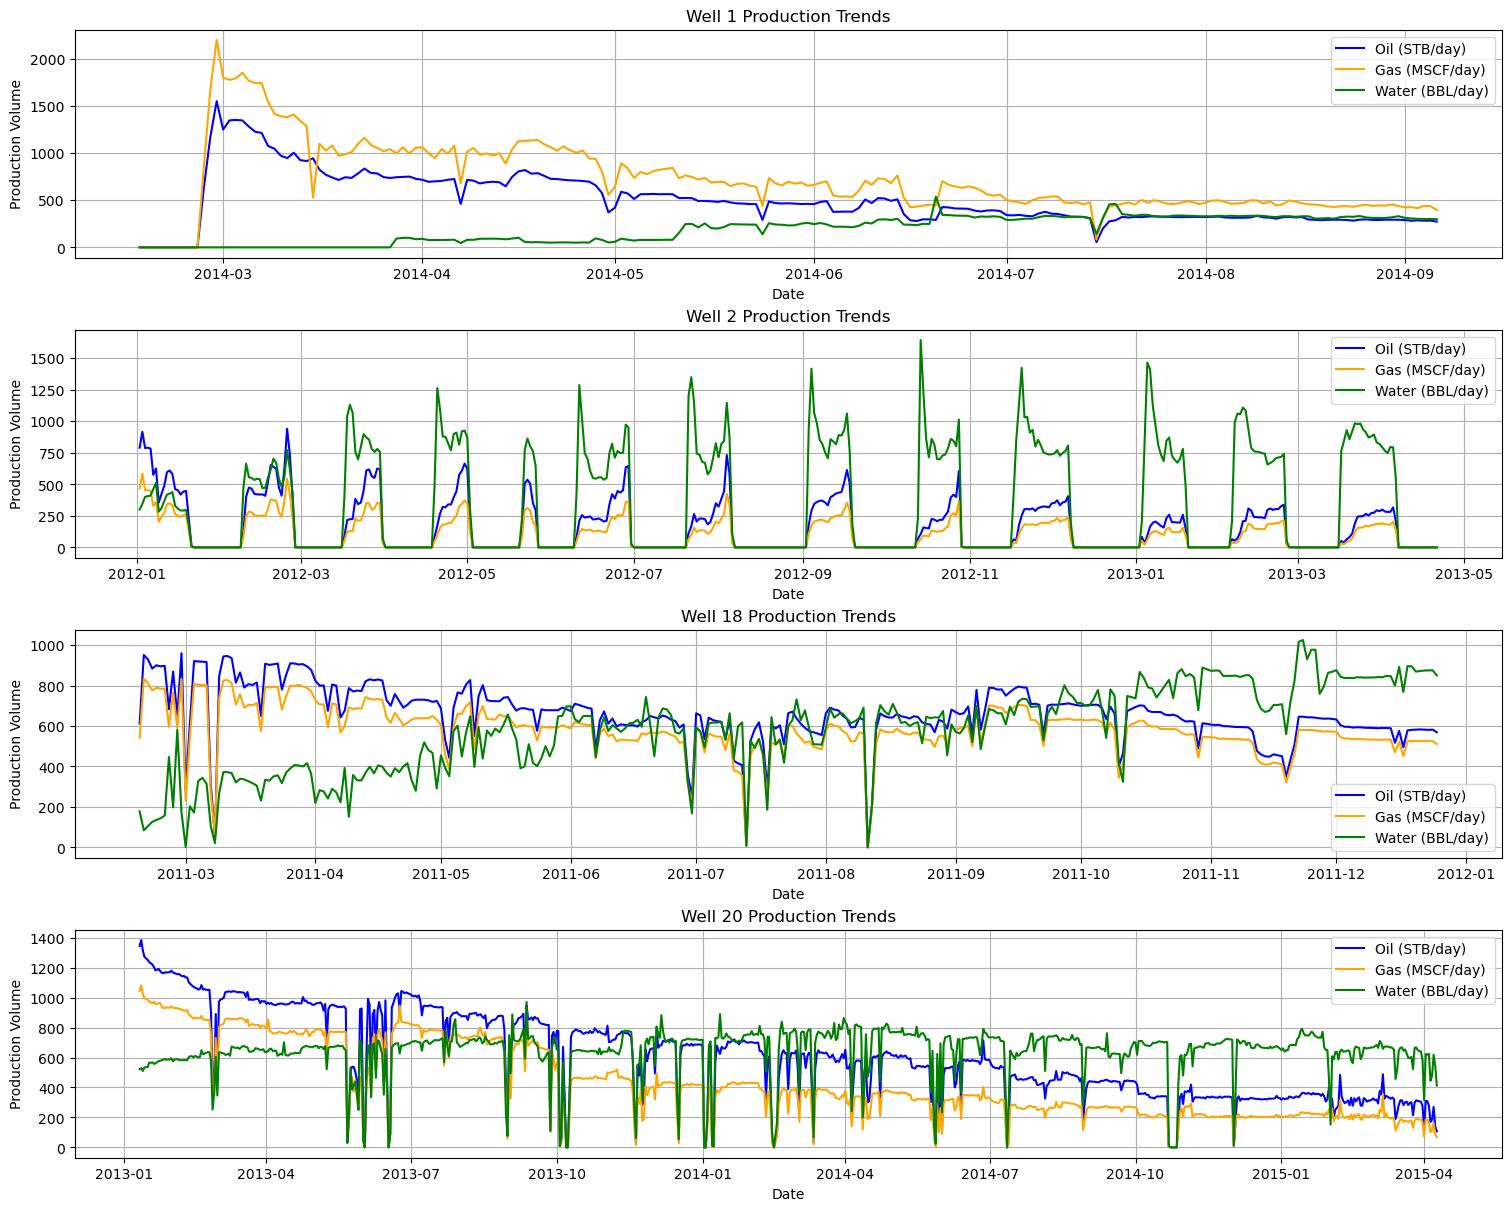

In [41]:
# Plot oil, gas, and water production trends across multiple wells
wells_to_plot = [1, 2, 18, 20]   # choose any wells you want
fig, axes = plt.subplots(len(wells_to_plot), 1, figsize=(15, 12), constrained_layout=True)

for i, well in enumerate(wells_to_plot):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    axes[i].plot(subset["date"], subset["oil_day"], label="Oil (STB/day)", color="blue")
    axes[i].plot(subset["date"], subset["gas_day"], label="Gas (MSCF/day)", color="orange")
    axes[i].plot(subset["date"], subset["water_day"], label="Water (BBL/day)", color="green")
    axes[i].set_title(f"Well {well} Production Trends")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Production Volume")
    axes[i].legend()
    axes[i].grid(True);

### Pressure and Production Trend Comparisons

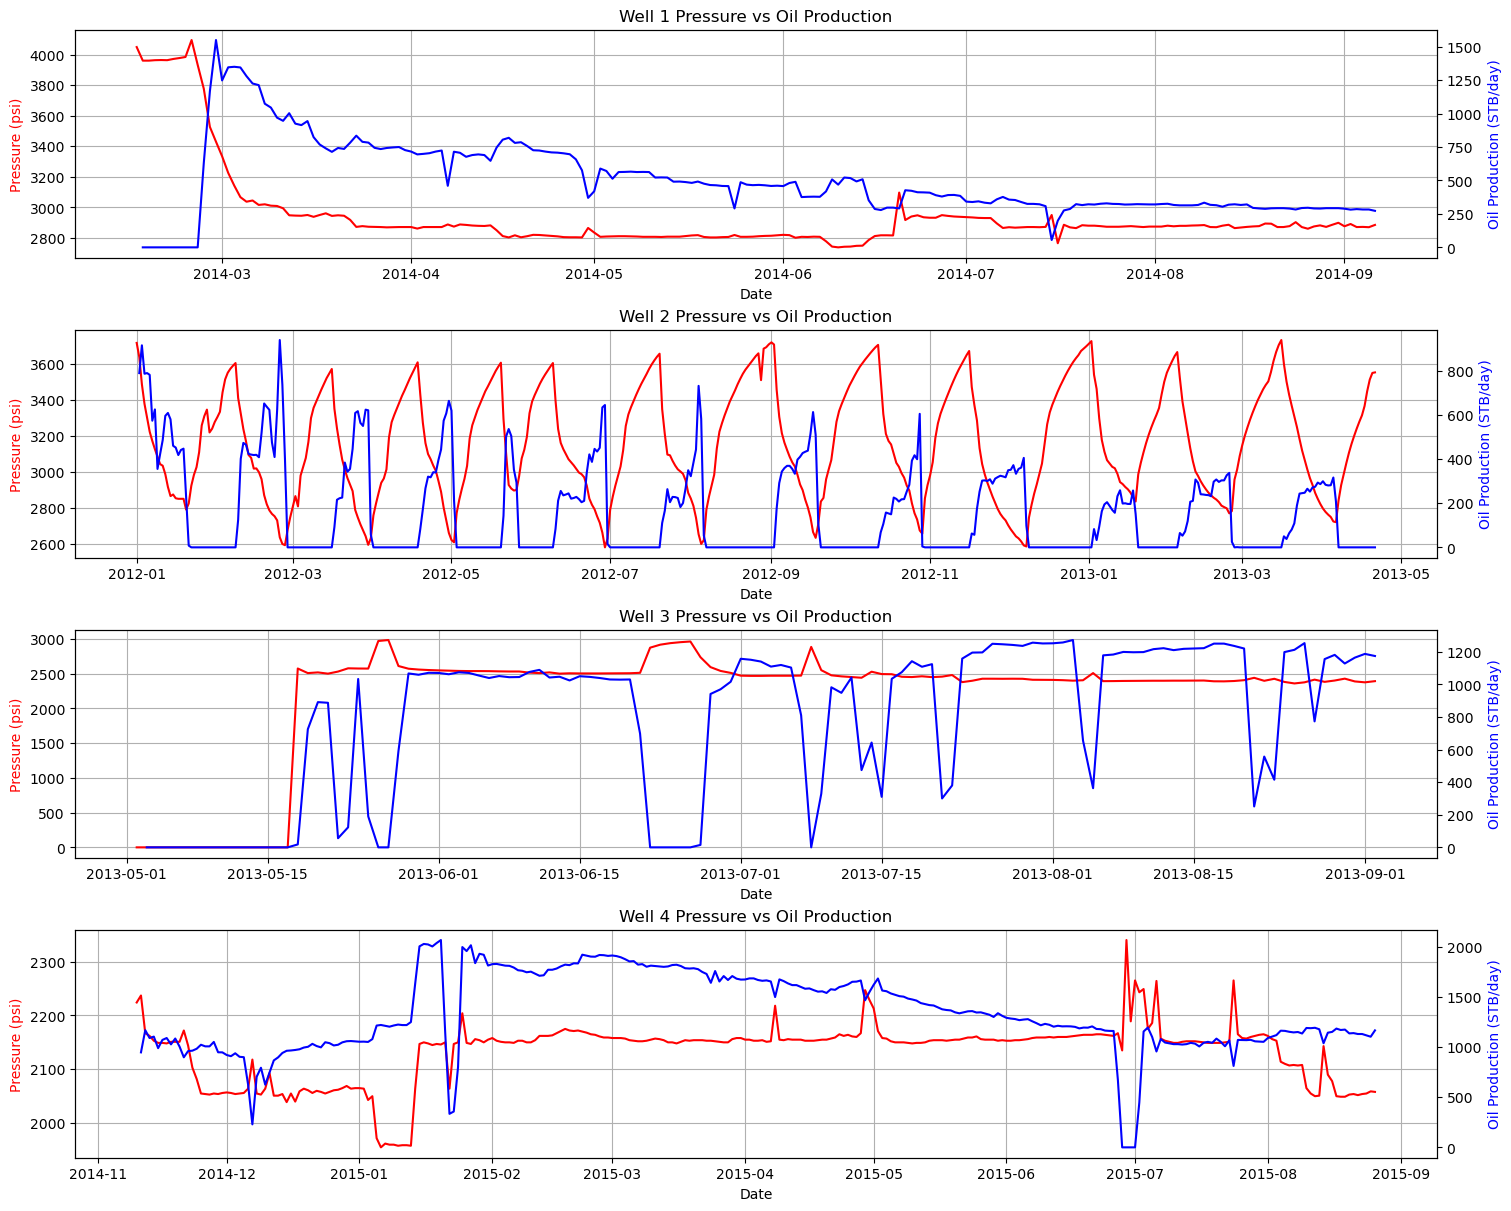

In [42]:
# Compare bottomhole pressure vs oil production for selected wells
wells_to_compare = [1, 2, 3, 4]
fig, axes = plt.subplots(len(wells_to_compare), 1, figsize=(15, 12), constrained_layout=True)

for i, well in enumerate(wells_to_compare):
    subset = wells_df[wells_df["well_name"] == well].sort_values("date")
    ax1 = axes[i]
    ax2 = ax1.twinx()
    
    ax1.plot(subset["date"], subset["bhp"], color="red", label="Bottomhole Pressure (psi)")
    ax2.plot(subset["date"], subset["oil_day"], color="blue", label="Oil Production (STB/day)")
    
    ax1.set_title(f"Well {well} Pressure vs Oil Production")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Pressure (psi)", color="red")
    ax2.set_ylabel("Oil Production (STB/day)", color="blue")
    ax1.grid(True);

### Cross-Well Behavioral Similarities

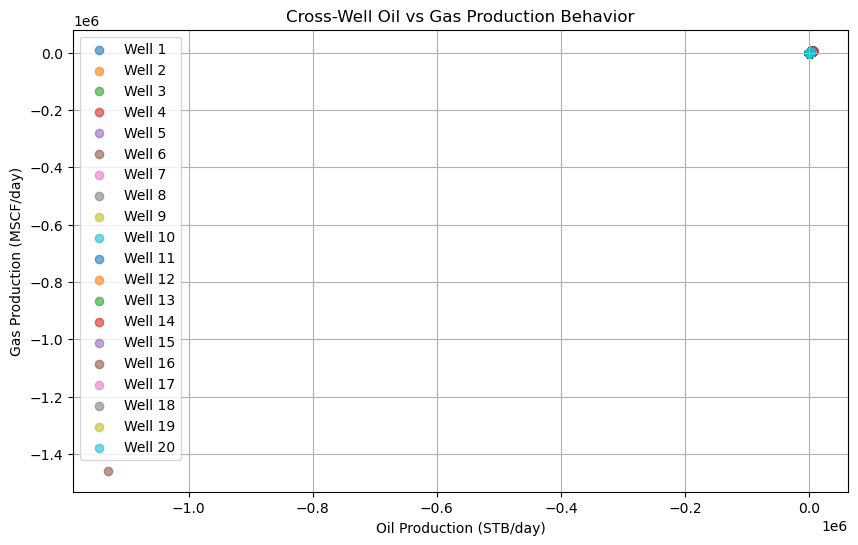

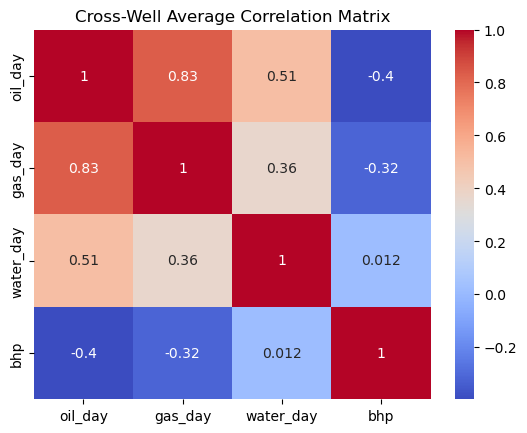

In [43]:
# Scatter plot comparing oil vs gas production across wells
plt.figure(figsize=(10,6))
for well in wells_df["well_name"].unique()[:20]:  # first 10 wells for clarity
    subset = wells_df[wells_df["well_name"] == well]
    plt.scatter(subset["oil_day"], subset["gas_day"], label=f"Well {well}", alpha=0.6)

plt.title("Cross-Well Oil vs Gas Production Behavior")
plt.xlabel("Oil Production (STB/day)")
plt.ylabel("Gas Production (MSCF/day)")
plt.legend()
plt.grid(True)
plt.show()

# Correlation heatmap across wells
pivot_df = wells_df.groupby("well_name")[["oil_day","gas_day","water_day","bhp"]].mean()
sns.heatmap(pivot_df.corr(), annot=True, cmap="coolwarm")
plt.title("Cross-Well Average Correlation Matrix");

# 4. Machine Learning Approach

### 1. Problem Definition
- **Goal**: Predict well performance trends (GOR trend, Watercut trend, PI trend) or classify wells into categories (Stable, Declining, Increasing, Combo).
- **Type of ML task**: Supervised classification (trend labels) or regression (predicting production rates).

---

### 2. Feature Engineering
Use the empirical analysis outputs as features:
- **Production features**: oil_day, gas_day, water_day, rolling averages.
- **Reservoir features**: reservoir type, saturation, average pressure, solution GOR.
- **Well features**: flow mechanism (GL/NF), choke size, annulus pressure.
- **Derived features**: GOR, watercut, PI.

# 5. Final Classification & Save